In [59]:
import pandas as pd
import sys
sys.path.append('/home/azureuser/cloudfiles/code/Users/manhductranvu/reeval-multi/mirt-official') 
from load_params import load_and_rotate

resmat = pd.read_pickle("../data/resmat.pkl")

theta, a, b = load_and_rotate(rotation='oblimax', model_path='./output/mirt_model_k19.pt')

# varimax, oblimax, quartimax, equamax, geomin_ort, promax, oblimin, quartimin, geomin_obl

# Step 1: Get the final theta tensor into a NumPy array
theta_abilities = theta
# Step 2: Create a labeled pandas DataFrame
# Use the model names from your original resmat for the index
model_names = resmat.index
factor_names = [f'F{i+1}' for i in range(theta.shape[1])]
ability_df = pd.DataFrame(theta_abilities, index=model_names, columns=factor_names)

--- Loading from Cache ---
Loaded cached theta shape: (183, 19)
Loaded cached a shape: (78712, 19)
Loaded cached b shape: (78712,)



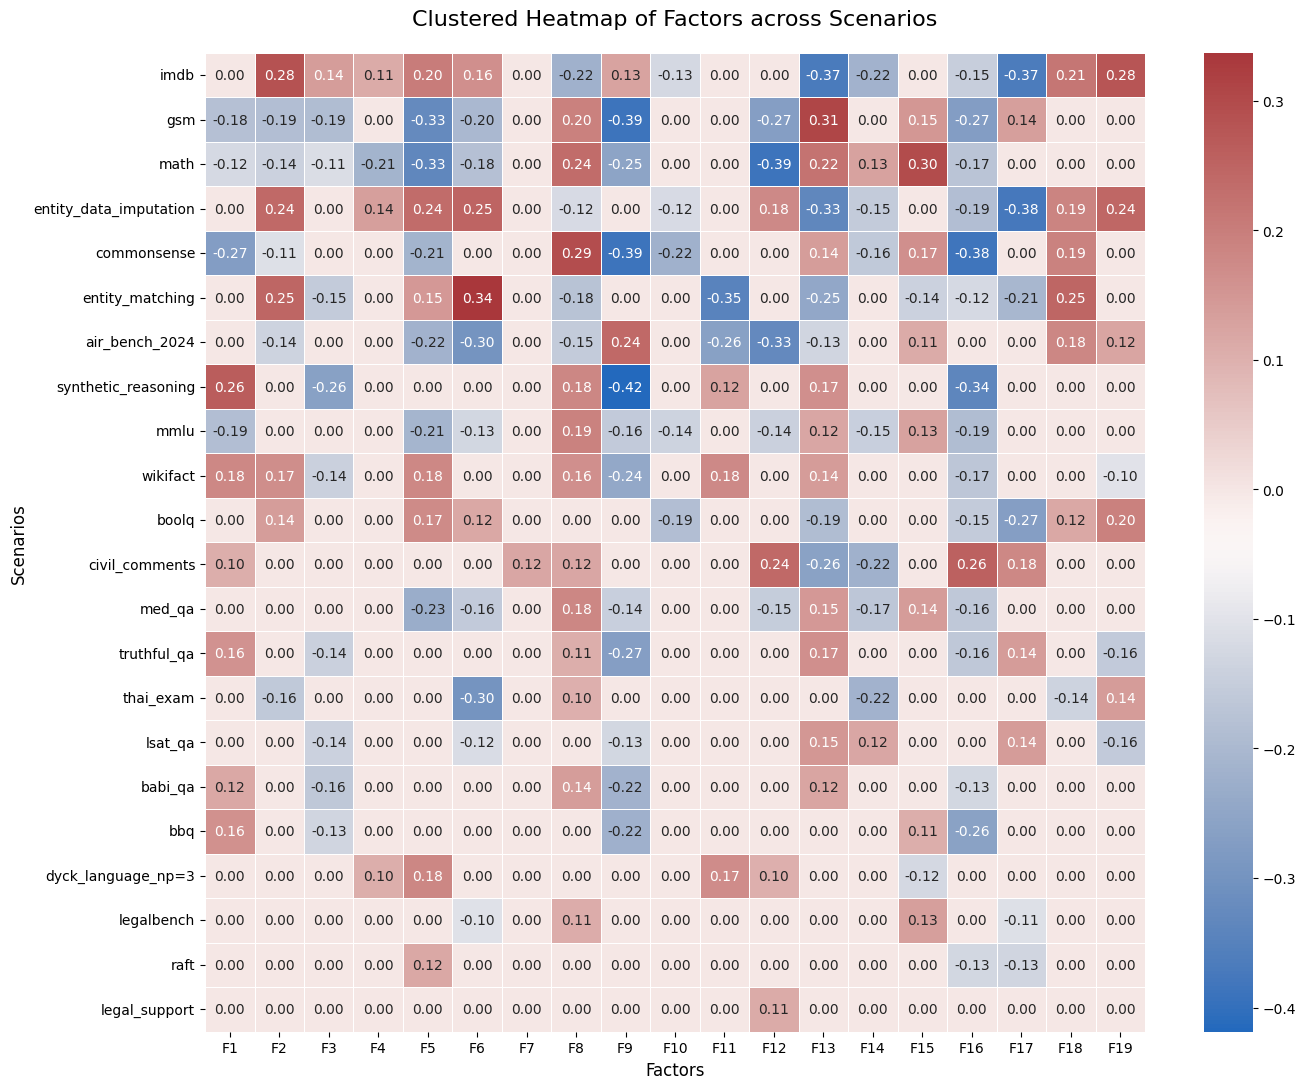

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sys.path.append('..') 
import style
plt.rcParams.update(style.rcparams)

a_df_scenarios = pd.DataFrame(a, index=resmat.columns.get_level_values('scenario'), columns=factor_names)
# Group by similar index values and calculate mean
a_df_grouped = a_df_scenarios.groupby(a_df_scenarios.index).mean().dropna()

# Check the resulting shape
print(f"Original a_df shape: {a_df_scenarios.shape}")
print(f"Grouped a_df shape: {a_df_grouped.shape}")
print(f"Number of unique scenarios: {len(a_df_grouped.index)}")


inspection = a_df_grouped.copy()
inspection[abs(inspection) < 0.1] = 0

# 1. Order rows by sum (scenarios with highest total loadings first) 
row_sums = inspection.abs().sum(axis=1)
row_order = row_sums.sort_values(ascending=False).index

# 2. Reorder inspection matrix - only reorder rows, keep columns in original order
ordered_inspection = inspection.loc[row_order, :]

# You can adjust figsize to make the plot larger or smaller for better readability.
fig, ax = plt.subplots(figsize=(14, 11))

# 2. Generate the clustered heatmap
# sns.heatmap is the core function here.
sns.heatmap(
    ordered_inspection,     # The clustered data to plot
    annot=True,       # Write the data value in each cell
    fmt=".2f",        # Use two decimal places for annotations
    cmap='vlag',  # Use the 'vlag' color map (blue-white-red)
    linewidths=.5,    # Add lines between cells
    ax=ax,
)

# 3. Add titles and labels for clarity
ax.set_title('Clustered Heatmap of Factors across Scenarios', fontsize=16, pad=20)
ax.set_xlabel('Factors', fontsize=12)
ax.set_ylabel('Scenarios', fontsize=12)

# 4. Ensure labels are not cut off
plt.tight_layout()

# 5. Display the plot
plt.show()

# To save the figure to a file, uncomment the line below
# fig.savefig('clustered_heatmap.png', dpi=300)

In [103]:
from sklearn.decomposition import PCA
import numpy as np

# theta is your factor score matrix
pca = PCA(n_components=1)
g_scores = pca.fit_transform(theta)[:, 0]  # general composite

In [ ]:
with pd.option_context('display.max_rows', 10):
  print(pd.DataFrame(g_scores, index=resmat.index, columns=['g_score']).sort_values(by='g_score', ascending=False))

In [ ]:
# import numpy as np
# import pandas as pd
# from sklearn.decomposition import PCA
# from factor_analyzer.rotator import Rotator
# from pathlib import Path

# # -------------------------
# # Inputs: replace as needed
# # -------------------------
# # a: numpy array (n_items x D)  -- item loadings from MIRT (unrotated or rotated)
# # theta: numpy array (n_persons x D) -- person/model scores in same coordinate system
# # item_names: list of length n_items (optional)
# # model_names: list of length n_persons (optional)

# item_names = resmat.columns.get_level_values('input.text').to_list()
# model_names = resmat.index.to_list()

# # validate shapes
# assert a.ndim == 2 and theta.ndim == 2 and a.shape[1] == theta.shape[1], "a and theta must be 2D and same D"
# n_items, D = a.shape
# n_persons = theta.shape[0]

# if 'item_names' not in globals():
#     item_names = [f"item_{i}" for i in range(n_items)]
# if 'model_names' not in globals():
#     model_names = [f"model_{i}" for i in range(n_persons)]

# out_dir = Path("./output/targeted_rotation")
# out_dir.mkdir(parents=True, exist_ok=True)

# # -------------------------
# # 1) Get PCA PC1 from theta
# # -------------------------
# pca = PCA(n_components=1)
# pc1_scores = pca.fit_transform(theta)[:, 0]        # (n_persons,)
# pc1_vec = pca.components_[0]                       # (D,) -- direction in the D-space
# # normalize to unit
# pc1_unit = pc1_vec / (np.linalg.norm(pc1_vec) + 1e-12)

# # -------------------------
# # 2) Build orthonormal basis Q with first column = pc1_unit
# # -------------------------
# # Fill matrix with pc1_unit and random columns for completion, then QR
# rng = np.random.RandomState(12345)
# random_mat = rng.normal(size=(D, D-1))
# M = np.column_stack([pc1_unit.reshape(-1, 1), random_mat])  # D x D
# Q, R_q = np.linalg.qr(M)  # Q is orthonormal, first column aligned to pc1_unit
# # small numerical fix: if first column sign mismatch, flip
# if np.dot(Q[:, 0], pc1_unit) < 0:
#     Q[:, 0] *= -1.0

# # Verify orthonormality
# orth_err = np.max(np.abs(Q.T @ Q - np.eye(D)))
# print(f"Orthonormality error: {orth_err:.2e}")

# # -------------------------
# # 3) Rotate a and theta with Q to align axis 0 with PC1
# # -------------------------
# a_q = a @ Q             # items x D
# theta_q = theta @ Q     # persons x D

# # Check that theta_q[:,0] matches pc1_scores up to scale
# corr_pc1 = np.corrcoef(theta_q[:, 0], pc1_scores)[0, 1]
# print(f"Correlation between theta_q[:,0] and PCA PC1 scores: {corr_pc1:.6f}")

# # Save intermediate results
# np.save(out_dir / "a_aligned_pc1.npy", a_q)
# np.save(out_dir / "theta_aligned_pc1.npy", theta_q)
# np.save(out_dir / "Q_initial.npy", Q)

# # -------------------------
# # 4) Optionally rotate remaining D-1 axes for interpretability
# #    (keep axis 0 fixed = PC1)
# # -------------------------
# do_rotate_subspace = True
# rot_method = "oblimax"   # 'varimax','oblimin','promax','oblimax', 'geomin_obl', etc.

# if do_rotate_subspace:
#     # Extract submatrix (items x (D-1)) corresponding to axes 1..D-1
#     A_sub = a_q[:, 1:]    # items x (D-1)
#     # apply chosen rotation (the Rotator expects variables x factors => same shape)
#     rot = Rotator(method=rot_method)
#     A_sub_rot = rot.fit_transform(A_sub)  # items x (D-1)
#     R_sub = rot.rotation_                 # (D-1) x (D-1) rotation in subspace

#     # Build final orthogonal rotation matrix Q_final = Q @ block_diag(1, R_sub)
#     # block_diag
#     Q_block = np.eye(D)
#     Q_block[1:, 1:] = R_sub
#     Q_final = Q @ Q_block

#     # Apply final rotation
#     a_final = a @ Q_final
#     theta_final = theta @ Q_final

#     # Save rotation pieces
#     np.save(out_dir / "R_sub.npy", R_sub)
#     np.save(out_dir / "Q_final.npy", Q_final)
#     np.save(out_dir / "a_final.npy", a_final)
#     np.save(out_dir / "theta_final.npy", theta_final)

#     print(f"Applied {rot_method} on the orthogonal complement. Saved a_final, theta_final.")
# else:
#     a_final = a_q.copy()
#     theta_final = theta_q.copy()
#     Q_final = Q.copy()

# # -------------------------
# # 5) Flip factor signs for interpretability
# # -------------------------
# # This new logic orients each factor based on its own loadings.
# # A common heuristic is to ensure the sum of loadings is positive.

# # We will modify a_final and theta_final in place
# a_used = a_final.copy()
# theta_used = theta_final.copy()

# print("\nOrienting factors for interpretability...")
# for d in range(D):
#     # Calculate the sum of all item loadings on this factor.
#     loading_sum = np.sum(a_used[:, d])
    
#     # If the sum is negative, the factor is likely reversed.
#     if loading_sum < 0:
#         # Flip the signs for both the loadings and the scores to correct it.
#         a_used[:, d] *= -1.0
#         theta_used[:, d] *= -1.0
#         print(f"Flipped Factor {d+1} (sum of loadings was {loading_sum:.2f})")

# # Now a_used and theta_used contain the final, interpretable results.

# # -------------------------
# # 6) Save and report results
# # -------------------------
# # (The rest of your saving code follows)

# df_theta = pd.DataFrame(theta_used, index=model_names, columns=[f"F{d+1}" for d in range(D)])
# df_a = pd.DataFrame(a_used, index=item_names, columns=[f"F{d+1}" for d in range(D)])

# df_theta.to_pickle(out_dir / "theta_rotated_aligned_with_pc1.pkl")
# df_a.to_pickle(out_dir / "a_rotated_aligned_with_pc1.pkl")

# # Top items per factor for human labeling
# top_items = {}
# for d in range(D):
#     order = np.argsort(-np.abs(a_used[:, d]))[:top_k]
#     top_items[f"F{d+1}"] = [(item_names[i], float(a_used[i, d])) for i in order]

# pd.DataFrame([
#     {"factor": k, "top_items": "; ".join([f"{name}({load:.3f})" for name, load in v])}
#     for k, v in top_items.items()
# ]).to_pickle(out_dir / "top_items_per_factor_aligned.pkl")

# print("Done. Results saved to:", out_dir)


In [27]:
# CONCISE REPLACEMENT using load_rotate_on_pc.py
import sys
sys.path.append('.')
import pandas as pd
from load_rotate_on_pc import load_and_rotate_pc1_targeted

resmat = pd.read_pickle("../data/resmat.pkl")

# Extract names for labeling
item_names = resmat.columns.get_level_values('input.text').to_list()
model_names = resmat.index.to_list()


df_theta, df_a, top_items_df, Q_final = load_and_rotate_pc1_targeted(
    model_path='./output/mirt_model_k19.pt',
    rotation_method='oblimax',  # 'varimax', 'promax', 'oblimin', etc. or None
    top_k=20,
    model_names=model_names,
    item_names=item_names
)

print("Targeted rotation complete! Results cached and factor signs flipped for interpretability.")
print(f"Theta shape: {df_theta.shape}")  
print(f"A shape: {df_a.shape}")
print(f"Top items per factor: {len(top_items_df)} factors")
df_theta['F1'] = -df_theta['F1'] + 2 # Shift the mean to 2
df_theta.sort_values(by='F1', ascending=False)

--- Loading from Cache ---
Loaded cached theta shape: (183, 19)
Loaded cached a shape: (78712, 19)
Loaded cached Q_final shape: (19, 19)

Targeted rotation complete! Results cached and factor signs flipped for interpretability.
Theta shape: (183, 19)
A shape: (78712, 19)
Top items per factor: 19 factors


,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14,F15,F16,F17,F18,F19
deepseek-ai/deepseek-v3,5.936767,0.056123,0.710099,-0.866881,0.307587,-0.593573,1.144066,-0.288701,0.712415,1.660664,1.073090,-0.080971,-0.302610,0.615789,-0.271380,0.004586,0.365629,0.262592,0.284084
meta/llama-3.2-90b-vision-instruct-turbo,5.846704,0.194756,0.695809,-0.641228,0.657238,0.223510,1.047123,0.133898,1.388597,0.365864,0.188582,-0.416122,0.502171,1.719426,-0.034182,-0.124043,0.950630,0.663107,-0.703331
meta/llama-3.1-70b-instruct-turbo,5.599271,0.219495,0.763784,-0.570462,0.372736,0.135513,1.133383,0.317537,1.582173,0.676883,0.566275,-0.684483,-0.059746,1.590281,-0.294336,-0.029262,0.592051,0.812728,-0.526337
meta/llama-3.1-405b-instruct-turbo,5.540441,-0.146455,-0.239814,-0.429016,1.294783,0.899672,0.563421,0.376775,1.380550,0.501558,0.089557,0.464172,0.085309,0.901731,0.205821,0.664357,1.147787,0.433321,0.531042
meta/llama-3.3-70b-instruct-turbo,5.515608,0.571522,-0.207485,-0.439783,0.900565,-0.089148,0.200243,0.165213,0.681017,0.069633,-0.099388,-0.005932,0.514724,1.442208,-0.219649,-0.022092,0.854940,0.917293,-0.995470
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ai21/j1-grande-v2-beta,-1.370109,1.476135,0.400099,0.515563,1.350656,0.484261,1.608754,-0.386632,1.011846,1.864664,2.038824,0.918520,-0.164147,1.177571,1.053341,0.941074,0.118073,-0.091542,-0.387924
ai21/j1-grande,-1.424745,0.869425,0.676223,-0.319973,0.719791,0.566026,0.774212,0.107244,0.170475,0.297545,-0.473293,0.172365,0.714632,0.817554,0.618293,1.693805,0.916703,0.620016,-0.850463
tiiuae/falcon-7b,-1.665491,0.681862,-0.348163,-0.452112,1.311307,-0.052198,0.482920,0.010838,0.970898,0.646488,0.717390,0.045887,0.060649,1.672656,0.639650,0.485137,1.022760,0.257617,0.914704
tiiuae/falcon-7b-instruct,-1.801904,0.552835,-0.303745,-0.232188,1.751486,-0.221565,0.263986,0.297178,1.179307,0.782832,0.656730,0.631804,0.185050,1.308961,0.178018,0.546179,1.196850,0.730078,1.147579


In [ ]:
top_k = 20  # Top items per scenario
loading_threshold = 0.1  # Minimum absolute loading for scenarios

a_df_questions = pd.DataFrame(df_a.values, index=resmat.columns.get_level_values('input.text'), columns=factor_names)

for col in a_df_questions.columns:
    with open('./output/factor_loadings_analysis_'+col+'.txt', 'w', encoding='utf-8') as f:
        f.write('='*80 + '\n')
        f.write(f'TOP LOADING ITEMS FOR FACTOR {col} (by Scenario)\n')
        f.write(f'Only scenarios with absolute loading > {loading_threshold}\n')
        f.write('='*80 + '\n')
        
        # Get scenarios with absolute loading > threshold
        qualifying_scenarios = a_df_grouped[abs(a_df_grouped[col]) > loading_threshold].index
        scenario_loadings = a_df_grouped.loc[qualifying_scenarios, col].sort_values(key=abs, ascending=False)
        
        f.write(f'\n📊 QUALIFYING SCENARIOS ({len(qualifying_scenarios)} total):\n')
        f.write('-'*50 + '\n')
        
        if len(qualifying_scenarios) == 0:
            f.write(f'No scenarios meet the threshold (|loading| > {loading_threshold})\n')
            f.write(f'Consider lowering the threshold or check factor loadings.\n\n')
            f.write('='*80 + '\n\n')
            continue
        
        for scenario, loading in scenario_loadings.items():
            f.write(f'{scenario}: {loading:.4f}\n')
        
        f.write('\n' + '='*80 + '\n')
        
        # For each qualifying scenario, get top loading questions
        for scenario in scenario_loadings.index:
            scenario_loading = scenario_loadings[scenario]
            
            # Get questions from this scenario
            scenario_mask = resmat.columns.get_level_values('scenario') == scenario
            scenario_questions = resmat.columns[scenario_mask].get_level_values('input.text')
            
            # Filter a_df_questions for this scenario
            scenario_question_loadings = a_df_questions.loc[scenario_questions, col].dropna()
            
            if len(scenario_question_loadings) == 0:
                continue
                
            f.write(f'\n🎯 SCENARIO: {scenario} (Factor Loading: {scenario_loading:.4f})\n')
            f.write('='*60 + '\n')
            
            # Get top positive loadings for this scenario
            if scenario_loading > 0:
                top_items = scenario_question_loadings.sort_values(ascending=False).head(top_k)
                f.write(f'📈 TOP {min(top_k, len(top_items))} POSITIVE LOADING ITEMS:\n')
            else:
                top_items = scenario_question_loadings.sort_values(ascending=True).head(top_k)
                f.write(f'📉 TOP {min(top_k, len(top_items))} NEGATIVE LOADING ITEMS:\n')
            
            f.write('-'*40 + '\n')
            
            for i, (question, loading) in enumerate(top_items.items(), 1):
                f.write(f'\n{i}. [[[Loading]]]: {loading:.4f}\n')
                f.write(f'   [[[Question]]]: {question}\n')
            
            f.write('\n' + '-'*60 + '\n')
        
        # Overall statistics
        f.write(f'\n📊 OVERALL STATISTICS FOR {col}:\n')
        f.write('-'*40 + '\n')
        f.write(f'Total scenarios analyzed: {len(qualifying_scenarios)}\n')
        f.write(f'Scenarios filtered out (|loading| <= {loading_threshold}): {len(a_df_grouped) - len(qualifying_scenarios)}\n')
        
        if len(scenario_loadings) > 0:
            f.write(f'Strongest scenario: {scenario_loadings.iloc[0]:.4f} ({scenario_loadings.index[0]})\n')
            f.write(f'Average absolute loading: {abs(scenario_loadings).mean():.3f}\n')
        else:
            f.write('No qualifying scenarios to analyze.\n')
        
        f.write('\n' + '='*80 + '\n\n')

print("Factor loadings analysis saved to individual files per factor")

Factor loadings analysis saved to individual files per factor


/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_23881/123790882.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a_df_grouped = a_df_scenarios.groupby(a_df_scenarios.index).mean().dropna()


Original a_df shape: (78712, 19)
Grouped a_df shape: (22, 19)
Number of unique scenarios: 22


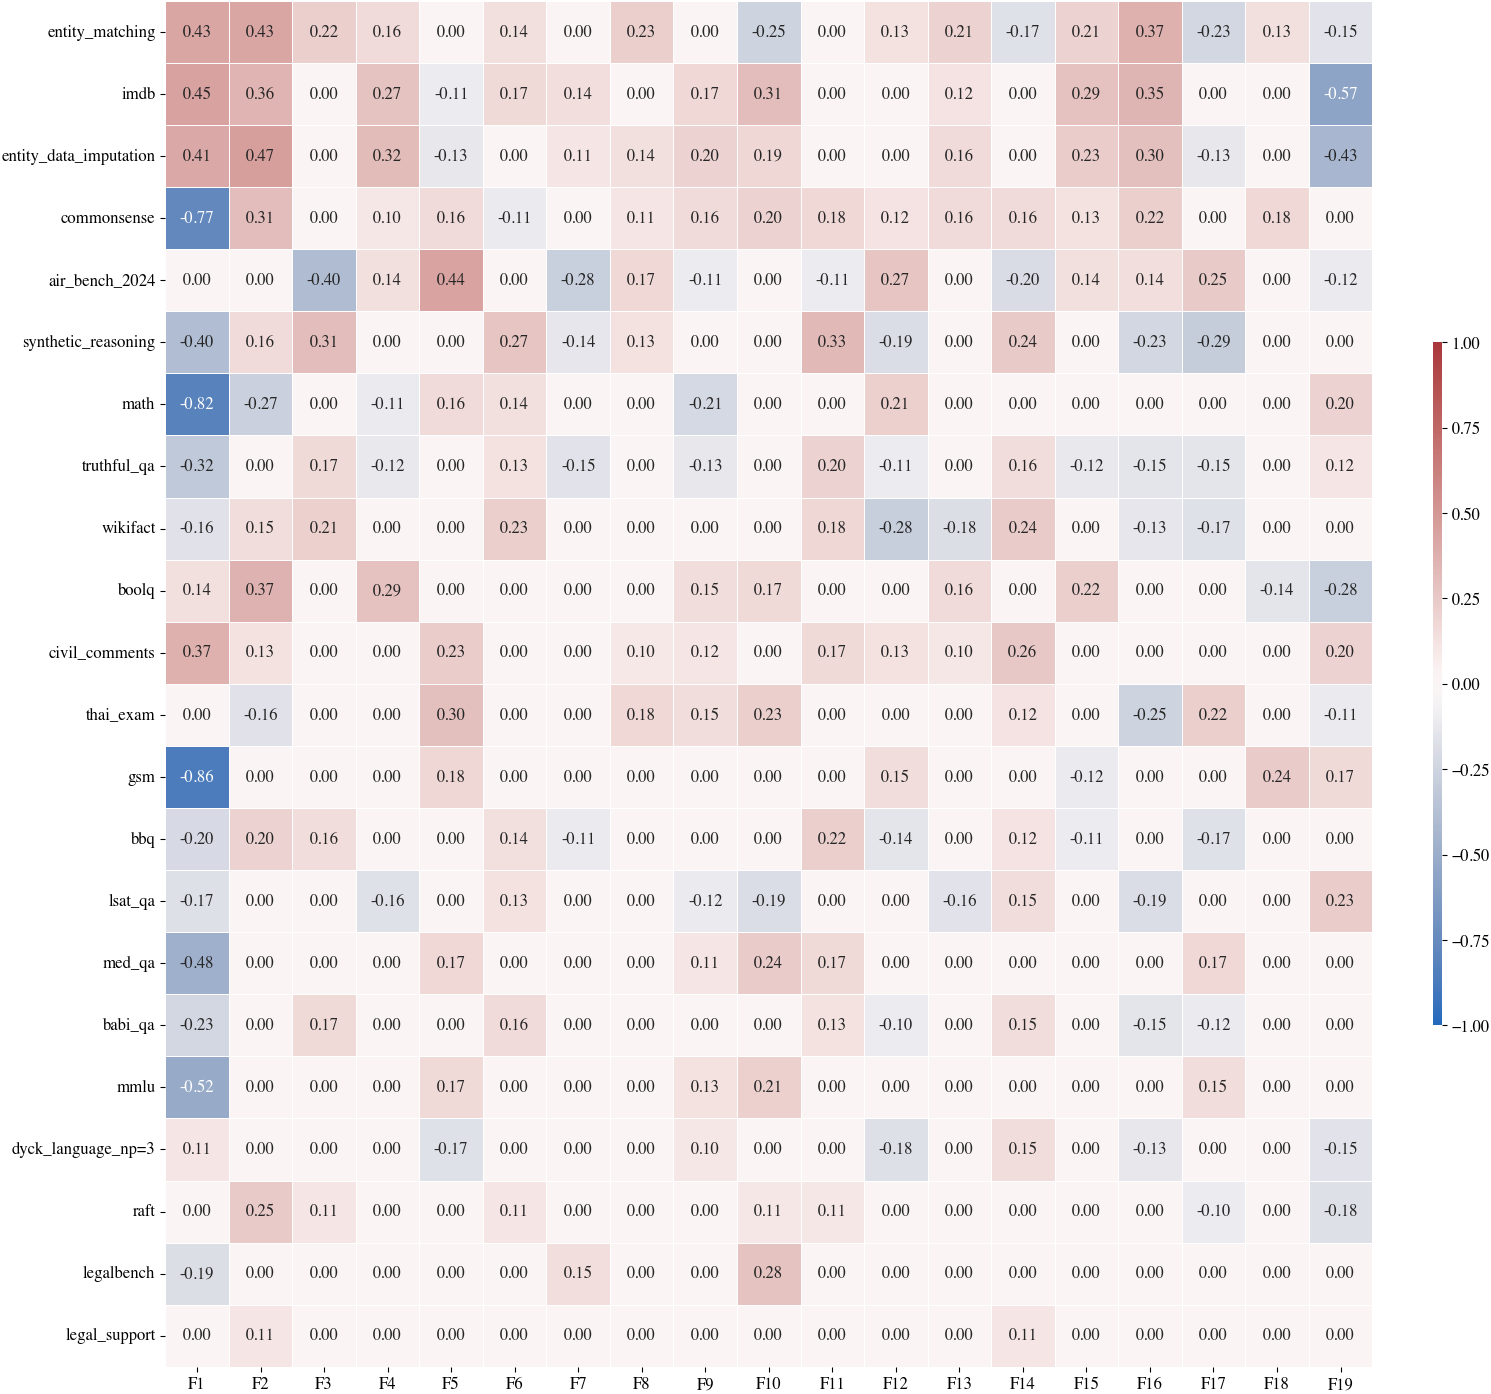

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


sys.path.append('..') 
import style
plt.rcParams.update(style.rcparams)

factor_names = [f'F{i+1}' for i in range(df_a.shape[1])]

a_df_scenarios = pd.DataFrame(df_a.values, index=resmat.columns.get_level_values('scenario'), columns=factor_names)
# Group by similar index values and calculate mean
a_df_grouped = a_df_scenarios.groupby(a_df_scenarios.index).mean().dropna()

# Check the resulting shape
print(f"Original a_df shape: {a_df_scenarios.shape}")
print(f"Grouped a_df shape: {a_df_grouped.shape}")
print(f"Number of unique scenarios: {len(a_df_grouped.index)}")


inspection = a_df_grouped.copy()
inspection[abs(inspection) < 0.1] = 0

# 1. Order rows by sum (scenarios with highest total loadings first) 
row_sums = inspection.abs().sum(axis=1)
row_order = row_sums.sort_values(ascending=False).index

# 2. Reorder inspection matrix - only reorder rows, keep columns in original order
ordered_inspection = inspection.loc[row_order, :]

# You can adjust figsize to make the plot larger or smaller for better readability.
fig, ax = plt.subplots(figsize=(15, 14))

# 2. Generate the clustered heatmap
# sns.heatmap is the core function here.
sns.heatmap(
    ordered_inspection,     # The clustered data to plot
    annot=True,       # Write the data value in each cell
    fmt=".2f",        # Use two decimal places for annotations
    cmap='vlag',  # Use the 'vlag' color map (blue-white-red)
    linewidths=.5,    # Add lines between cells
    ax=ax,
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={'shrink': 0.5, 'aspect': 75}
)

# 3. Add titles and labels for clarity
ax.set_xlabel('')
ax.set_ylabel('')

# 4. Ensure labels are not cut off
# plt.tight_layout()

# 5. Display the plot
plt.show()

# To save the figure to a file, uncomment the line below
fig.savefig('../result/clustered_heatmap_.pdf', bbox_inches='tight')

In [29]:
score_1 = pd.Series(df_theta['F1'], index=resmat.index)
score_2 = pd.Series(df_theta['F1'] + df_theta['F2'], index=resmat.index)
score_3 = pd.Series(df_theta['F1'] + df_theta['F3'], index=resmat.index)
score_4 = pd.Series(df_theta['F1'] + df_theta['F4'], index=resmat.index)
score_5 = pd.Series(df_theta['F1'] + df_theta['F5'], index=resmat.index)
score_6 = pd.Series(df_theta['F1'] + df_theta['F6'], index=resmat.index)
score_7 = pd.Series(df_theta['F1'] + df_theta['F7'], index=resmat.index)
score_8 = pd.Series(df_theta['F1'] + df_theta['F8'], index=resmat.index)
score_9 = pd.Series(df_theta['F1'] + df_theta['F9'], index=resmat.index)
score_10 = pd.Series(df_theta['F1'] + df_theta['F10'], index=resmat.index)
score_11 = pd.Series(df_theta['F1'] + df_theta['F11'], index=resmat.index)
score_12 = pd.Series(df_theta['F1'] + df_theta['F12'], index=resmat.index)
score_13 = pd.Series(df_theta['F1'] + df_theta['F13'], index=resmat.index)
score_14 = pd.Series(df_theta['F1'] + df_theta['F14'], index=resmat.index)
score_15 = pd.Series(df_theta['F1'] + df_theta['F15'], index=resmat.index)
score_16 = pd.Series(df_theta['F1'] + df_theta['F16'], index=resmat.index)
score_17 = pd.Series(df_theta['F1'] + df_theta['F17'], index=resmat.index)
score_18 = pd.Series(df_theta['F1'] + df_theta['F18'], index=resmat.index)
score_19 = pd.Series(df_theta['F1'] + df_theta['F19'], index=resmat.index)

In [62]:
# Assuming 'resmat' is your DataFrame where rows represent test-takers

# 1. Count the NaN values for each row (test-taker)
nan_counts = resmat.isnull().sum(axis=1)

# 2. Sort the results to find the test-takers with the least NaNs
sorted_nan_counts = nan_counts.sort_values()

# 3. Select the top 10 and print the result
top_10_with_least_nan = sorted_nan_counts.head(100)

with pd.option_context('display.max_rows', None):
  print(top_10_with_least_nan)

request.model
openai/gpt-3.5-turbo-0613                    2295
meta/llama-2-7b                              7280
mistralai/mistral-7b-v0.1                    7280
meta/llama-2-13b                             7280
meta/llama-2-70b                             7280
AlephAlpha/luminous-extended                18765
openai/text-davinci-002                     18765
openai/text-davinci-003                     18765
AlephAlpha/luminous-supreme                 18765
ai21/j2-grande                              18765
AlephAlpha/luminous-base                    18765
ai21/j2-jumbo                               18765
openai/gpt-3.5-turbo-0301                   20444
tiiuae/falcon-7b                            20503
meta/llama-65b                              20503
tiiuae/falcon-40b                           20503
openai/text-curie-001                       23691
openai/text-ada-001                         23691
openai/text-babbage-001                     23691
cohere/medium-20221108              

request.model
meta/llama-3.1-405b-instruct-turbo    6.025140
meta/llama-3.1-70b-instruct-turbo     5.965838
meta/llama-3.1-8b-instruct-turbo      3.350440
meta/llama-65b                        2.023543
dtype: float64
request.model
openai/gpt-4o-2024-05-13         5.911171
openai/gpt-4-turbo-2024-04-09    5.220473
openai/gpt-4o-mini-2024-07-18    4.645817
openai/text-davinci-002          2.556793
dtype: float64
request.model
anthropic/claude-3-opus-20240229       4.692847
anthropic/claude-3-sonnet-20240229     3.505601
anthropic/claude-3-haiku-20240307      3.252650
anthropic/stanford-online-all-v4-s3    1.612668
dtype: float64


/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_23881/2827072815.py:229: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


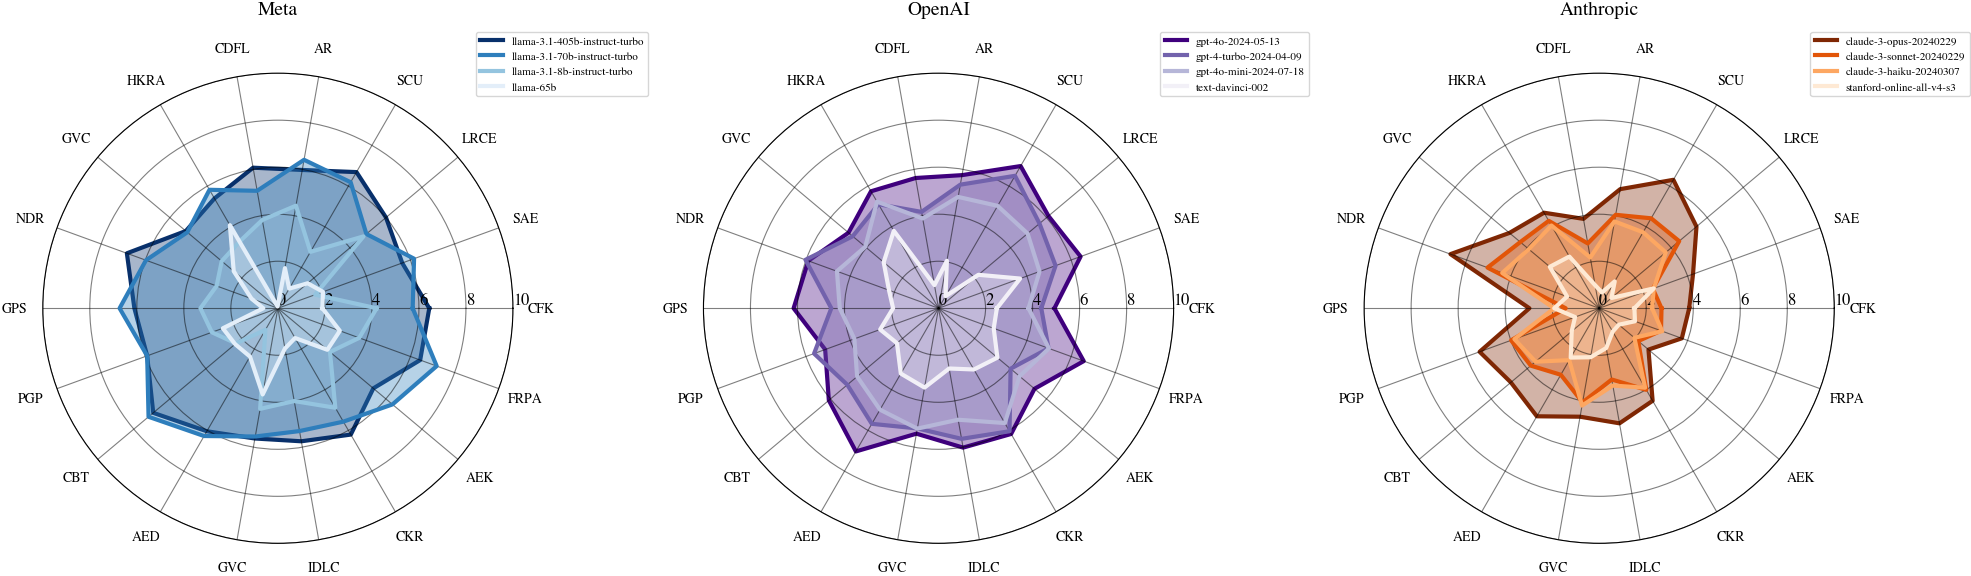

Selected models for radar charts:

META:
  meta/llama-3.1-405b-instruct-turbo
  meta/llama-3.1-70b-instruct-turbo
  meta/llama-3.1-8b-instruct-turbo
  meta/llama-65b

OPENAI:
  openai/gpt-4o-2024-05-13
  openai/gpt-4-turbo-2024-04-09
  openai/gpt-4o-mini-2024-07-18
  openai/text-davinci-002

ANTHROPIC:
  anthropic/claude-3-opus-20240229
  anthropic/claude-3-sonnet-20240229
  anthropic/claude-3-haiku-20240307
  anthropic/stanford-online-all-v4-s3


In [65]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from math import pi
sys.path.append('..') 
import style
plt.rcParams.update(style.rcparams)

common_indices = [
'anthropic/claude-3-sonnet-20240229', 'anthropic/claude-3-opus-20240229', 'anthropic/claude-3-haiku-20240307', 'anthropic/stanford-online-all-v4-s3',
'meta/llama-3.1-8b-instruct-turbo', 'meta/llama-3.1-70b-instruct-turbo', 'meta/llama-3.1-405b-instruct-turbo', 'meta/llama-65b',
'openai/gpt-4o-2024-05-13', 'openai/gpt-4o-mini-2024-07-18', 'openai/gpt-4-turbo-2024-04-09', 'openai/text-davinci-002'
]

scores_mapping = {
    # 'F1': score_1,
    'F2': score_2,
    'F3': score_3,
    'F4': score_4,
    'F5': score_5,
    'F6': score_6,
    'F7': score_7,
    'F8': score_8,
    'F9': score_9,
    'F10': score_10,
    'F11': score_11,
    'F12': score_12,
    'F13': score_13,
    'F14': score_14,
    'F15': score_15,
    'F16': score_16,
    'F17': score_17,
    'F18': score_18,
    'F19': score_19,
}

skill_scores = pd.DataFrame(scores_mapping)

# Psychometric Groupings of AI Capability Dimensions

cognitive_architecture_and_reasoning = {
    'F6': ('Abstract Rule-Based and Symbolic Reasoning', 'AR'),
    'F11': ('General Problem Solving', 'GPS'),
    'F12': ('Procedural and Generative Planning', 'PGP'),
    'F17': ('Complex, Knowledge-Intensive Reasoning', 'CKR'),
    'F18': ('Application of External Knowledge and Procedures', 'AEK'),
    'F19': ('Formal Reasoning and Procedural Adherence', 'FRPA')
}

language_and_knowledge_application = {
    # 'F1',   # Surface-Level Textual Pattern Matching and Classification
    'F2': ('Contextual Fact-Finding and Knowledge Retrieval', 'CFK'),
    'F4': ('Literal Reading Comprehension and Direct Information Extraction', 'LRCE'),
    'F5': ('Sophisticated Contextual Understanding and Complex Generation', 'SCU'),
    'F7': ('Comprehension of Dense and Formal Language', 'CDFL'),
    'F8': ('High-Fidelity Knowledge Representation and Application', 'HKRA'),
    'F9': ('General Verbal Comprehension', 'GVC'),
    'F10': ('Narrative and Descriptive Reasoning', 'NDR'),
    'F13': ('Context-Bound Textual Analysis', 'CBT'),
    'F15': ('General Verbal Comprehension', 'GVC'),
    'F16': ('Informal and Descriptive Language Comprehension', 'IDLC')
}

behavioral_style_and_alignment = {
    'F3': ('Safety and Ethics Alignment', 'SAE'),
    'F14': ('Analytical and Expansive Discourse', 'AED')
}

# Consolidating all dimensions into a single structure
ai_capability_framework = {
    "Cognitive Architecture & Reasoning": cognitive_architecture_and_reasoning,
    "Language Processing & Knowledge Application": language_and_knowledge_application,
    "Behavioral Style & Alignment": behavioral_style_and_alignment
}

all_capability_dims = {
    **cognitive_architecture_and_reasoning,
    **language_and_knowledge_application,
    **behavioral_style_and_alignment
}

abbreviated_labels = [all_capability_dims[col][1] for col in skill_scores.columns]

skill_scores = skill_scores[list(all_capability_dims.keys())]

skill_scores = skill_scores.loc[common_indices]

# Function to create radar chart
def create_radar_chart(data, labels, title, ax, colors=None, model_names=None):
    """
    Create a radar chart for given data
    """
    # Number of variables
    N = len(labels)
    
    # Compute angle for each axis
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]  # Complete the circle
    
    # Initialize colors if not provided
    if colors is None:
        colors = plt.cm.tab10(np.linspace(0, 1, len(data)))
    
    # Plot each model
    for i, (model_data, color) in enumerate(zip(data, colors)):
        values = model_data.tolist()
        values += values[:1]  # Complete the circle
        
        model_name = model_names[i] if model_names else f'Model {i+1}'
        # Extract just the model name after the company prefix
        display_name = model_name.split('/')[-1] if '/' in model_name else model_name
        
        ax.plot(angles, values, '-', linewidth=3, label=display_name, color=color, alpha=1, zorder=i + 1)
        ax.fill(angles, values, color=color, alpha=0.35)
    
    # Add labels
    ax.tick_params(pad=10)
    range_ax = range(0, 11, 2)
    ax.set_ylim(range_ax[0], range_ax[-1])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=10, weight='bold')
    ax.set_title(title, size=14, weight='bold', pad=20)
    ax.grid(True, alpha=0.5, color='black')
    
    # Ensure y-ticks align with circles
    ax.set_rgrids(range_ax, angle=0, labels=range_ax, fontsize=12)

    # Hide the zero label
    ax.set_rmin(range_ax[0])

# Filter and group models by company
companies = {
    'meta': [],
    'openai': [], 
    'anthropic': []
}

# Group models by company prefix (only include models that have all 4 skill scores)
common_models = skill_scores.dropna().index
for model in common_models:
    if model.startswith('meta/'):
        companies['meta'].append(model)
    elif model.startswith('openai/'):
        companies['openai'].append(model)
    elif model.startswith('anthropic/'):
        companies['anthropic'].append(model)

# UPDATED VERSION: Select top models from each company with explicit model inclusion
def select_top_models(models, n=6, explicit_models=None):
    """
    Select top models from a list, with option to include explicit models.
    
    Args:
        models: List of model names to choose from
        n: Number of top models to select
        explicit_models: List of model names that must be included if they exist in models
        
    Returns:
        List of selected model names
    """
    if not models:
        return []
    
    # Initialize result with explicit models that exist in the models list
    result = []
    if explicit_models:
        result = [model for model in explicit_models if model in models]
    
    # If we already have enough models from explicit list, return them
    if len(result) >= n:
        return result[:n]
    
    # Get model scores and sort by performance
    model_scores = skill_scores.loc[models].mean(axis=1).sort_values(ascending=False)
    print(model_scores)
    
    # Add top performing models that aren't already in the result
    remaining_slots = n - len(result)
    for model in model_scores.index:
        if model not in result:
            result.append(model)
            remaining_slots -= 1
            if remaining_slots == 0:
                break
    
    return result

# Get top models for each company with explicit model inclusion
selected_models = {
    company: select_top_models(
        models,
        n=6,
    ) 
    for company, models in companies.items()
}
# Create the radar charts
fig, axes = plt.subplots(1, 3, figsize=(20, 12), subplot_kw=dict(projection='polar'))
axes = axes.flatten()

# Skill labels 
skill_labels = scores_mapping.keys()

company_names = ['Meta', 'OpenAI', 'Anthropic']
company_keys = ['meta', 'openai', 'anthropic']

for i, (company_key, company_name) in enumerate(zip(company_keys, company_names)):
    models = selected_models[company_key]
    if models:
        # Get data for selected models using skill scores
        model_data = skill_scores.loc[models].values
        
        # Create color palette for this company
        if company_key == 'meta':
            colors = plt.cm.Blues_r(np.linspace(0, 0.9, len(models)))
        elif company_key == 'openai':
            colors = plt.cm.Purples_r(np.linspace(0, 0.9, len(models)))
        elif company_key == 'anthropic':
            colors = plt.cm.Oranges_r(np.linspace(0, 0.9, len(models)))
        create_radar_chart(model_data, abbreviated_labels, company_name, axes[i],
                         colors=colors, model_names=models)
        
        # Add legend with abbreviated names
        axes[i].legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)
    else:
        axes[i].text(0.5, 0.5, f'No {company_name} models found', 
                    transform=axes[i].transAxes, ha='center', va='center')
        axes[i].set_title(company_name, size=14, weight='bold', pad=20)

plt.tight_layout()
plt.savefig('../result/model_families_all_skill_radar_charts.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Print summary of selected models and their scores
print("Selected models for radar charts:")
for company, models in selected_models.items():
    print(f"\n{company.upper()}:")
    for model in models:
        scores = skill_scores.loc[model]
        print(f"  {model}")